In [31]:
import sys

print(sys.executable)

d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\.venv\Scripts\python.exe


In [32]:
import os
import sys
import subprocess
from pathlib import Path

# ============================================================
# PROJECT SETUP
# Hỗ trợ Google Colab và VS Code/Jupyter
# ============================================================

REPO_URL = "https://github.com/pnga1206/market-risk-measurement.git"
BRANCH = "feature/notebook"
REPO_NAME = "market-risk-measurement"

if "google.colab" in sys.modules:
    # Google Colab
    ROOT = Path("/content") / REPO_NAME

    if not ROOT.exists():
        subprocess.run(
            [
                "git", "clone",
                "--branch", BRANCH,
                "--single-branch",
                REPO_URL,
                str(ROOT)
            ],
            check=True
        )
    else:
        subprocess.run(
            ["git", "-C", str(ROOT), "fetch", "origin"],
            check=True
        )
        subprocess.run(
            ["git", "-C", str(ROOT), "checkout", BRANCH],
            check=True
        )
        subprocess.run(
            ["git", "-C", str(ROOT), "pull", "--ff-only", "origin", BRANCH],
            check=True
        )

else:
    # VS Code / Jupyter local
    ROOT = Path.cwd()

    if ROOT.name == "notebooks":
        ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Cài thư viện tự động khi chạy trên Colab
if "google.colab" in sys.modules:
    requirements_file = ROOT / "requirements.txt"

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(requirements_file)
    ])

print("Project root:", ROOT)
print("Environment:", "Google Colab" if "google.colab" in sys.modules else "Local")
print("Python:", sys.executable)

Project root: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement
Environment: Local
Python: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\.venv\Scripts\python.exe


In [33]:
import numpy as np
import pandas as pd
import scipy
import arch
import matplotlib.pyplot as plt

from pathlib import Path

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Arch:", arch.__version__)

NumPy: 2.5.3
Pandas: 3.0.6
SciPy: 1.18.1
Arch: 8.0.0


In [34]:
# ============================================================
# DATA PATH
# ============================================================

DATA_DIR = ROOT / "data" / "main"
OUTPUT_TABLES = ROOT / "outputs" / "tables"
OUTPUT_FIGURES = ROOT / "outputs" / "figures"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Data folder:", DATA_DIR)
print("Output tables:", OUTPUT_TABLES)
print("Output figures:", OUTPUT_FIGURES)

Data folder: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\data\main
Output tables: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\outputs\tables
Output figures: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\outputs\figures


In [35]:
print("Files in data/main:")

for file in sorted(DATA_DIR.iterdir()):
    print("-", file.name)

Files in data/main:
- fx_raw.csv
- portfolio_aligned.csv
- portfolio_returns.csv
- sp500_raw.csv
- vnindex_raw.csv


In [36]:
# ============================================================
# LOAD PORTFOLIO DATA
# ============================================================

returns_path = DATA_DIR / "portfolio_returns.csv"

returns = pd.read_csv(returns_path)

returns["date"] = pd.to_datetime(returns["date"])
returns = returns.sort_values("date").reset_index(drop=True)

print("Shape:", returns.shape)
print("Columns:")
print(list(returns.columns))

print("\nDate range:")
print(returns["date"].min(), "→", returns["date"].max())

returns.head()

Shape: (2382, 8)
Columns:
['date', 'vnindex_close', 'sp500_close_usd', 'usd_vnd', 'sp500_close_vnd', 'vnindex_return', 'sp500_vnd_return', 'portfolio_return']

Date range:
2016-09-27 00:00:00 → 2026-09-24 00:00:00


,date,vnindex_close,sp500_close_usd,usd_vnd,sp500_close_vnd,vnindex_return,sp500_vnd_return,portfolio_return
0,2016-09-27,684.89,2159.93,22018.0,47557338.74,0.011528,0.009972,0.010750
1,2016-09-28,686.72,2171.37,21956.0,47674599.72,0.002668,0.002463,0.002566
2,2016-09-29,688.55,2151.13,21945.0,47206547.85,0.002661,-0.009866,-0.003602
3,2016-09-30,686.00,2168.27,21797.0,47261781.19,-0.003710,0.001169,-0.001270
4,2016-10-03,683.05,2161.20,22004.0,47555044.80,-0.004310,0.006186,0.000938


In [37]:
# ============================================================
# DATA QUALITY CHECK
# ============================================================

print("Missing values:")
print(returns.isna().sum())

print("\nDuplicate dates:", returns["date"].duplicated().sum())

print("\nData types:")
print(returns.dtypes)

Missing values:
date                0
vnindex_close       0
sp500_close_usd     0
usd_vnd             0
sp500_close_vnd     0
vnindex_return      0
sp500_vnd_return    0
portfolio_return    0
dtype: int64

Duplicate dates: 0

Data types:
date                datetime64[us]
vnindex_close              float64
sp500_close_usd            float64
usd_vnd                    float64
sp500_close_vnd            float64
vnindex_return             float64
sp500_vnd_return           float64
portfolio_return           float64
dtype: object


In [38]:
# ============================================================
# PORTFOLIO RETURN SUMMARY
# ============================================================

portfolio_returns = returns["portfolio_return"].dropna()

print(portfolio_returns.describe())

count    2382.000000
mean        0.000506
std         0.009099
min        -0.076614
25%        -0.003535
50%         0.001056
75%         0.005370
max         0.058284
Name: portfolio_return, dtype: float64


In [39]:
# ============================================================
# PREPARE RETURN SERIES
# ============================================================

portfolio_return_series = (
    returns
    .set_index("date")["portfolio_return"]
    .dropna()
    .sort_index()
)

print("Number of observations:", len(portfolio_return_series))
print("Start:", portfolio_return_series.index.min())
print("End:", portfolio_return_series.index.max())

Number of observations: 2382
Start: 2016-09-27 00:00:00
End: 2026-09-24 00:00:00


In [40]:
# ============================================================
# IMPORT VaR MODELS
# ============================================================

from src.var.var_models import (
    calculate_historical_var,
    calculate_parametric_var,
    calculate_monte_carlo_var,
    run_rolling_var
)

from src.config import CONF_LEVEL, MC_SIMULATIONS, RANDOM_SEED

print("Confidence level:", CONF_LEVEL)
print("Monte Carlo simulations:", MC_SIMULATIONS)
print("Random seed:", RANDOM_SEED)

Confidence level: 0.975
Monte Carlo simulations: 10000
Random seed: 42


In [41]:
# ============================================================
# VaR 97.5% - 1 DAY
# ============================================================

var_historical = calculate_historical_var(
    portfolio_return_series,
    conf_level=CONF_LEVEL
)

var_parametric = calculate_parametric_var(
    portfolio_return_series,
    conf_level=CONF_LEVEL
)

var_monte_carlo = calculate_monte_carlo_var(
    portfolio_return_series,
    conf_level=CONF_LEVEL,
    n_sims=MC_SIMULATIONS,
    seed=RANDOM_SEED
)

var_summary = pd.DataFrame({
    "Method": [
        "Historical",
        "Parametric",
        "Monte Carlo"
    ],
    "VaR": [
        var_historical,
        var_parametric,
        var_monte_carlo
    ]
})

var_summary["VaR (%)"] = var_summary["VaR"] * 100

var_summary

,Method,VaR,VaR (%)
0,Historical,0.019427,1.942651
1,Parametric,0.017328,1.732783
2,Monte Carlo,0.017406,1.740564


In [42]:
# ============================================================
# ROLLING VaR 97.5%
# Window = 250 trading days
# ============================================================

ROLLING_WINDOW = 250

rolling_var = run_rolling_var(
    portfolio_return_series,
    window=ROLLING_WINDOW,
    conf_level=CONF_LEVEL
)

print("Shape:", rolling_var.shape)
print("Start:", rolling_var.index.min())
print("End:", rolling_var.index.max())

rolling_var.head()

Shape: (2132, 3)
Start: 2017-10-05 00:00:00
End: 2026-09-24 00:00:00


,VaR_Historical,VaR_Parametric,VaR_MonteCarlo
Date,,,
2017-10-05,0.009503,0.009302,0.009272
2017-10-06,0.009503,0.009259,0.009262
2017-10-09,0.009503,0.009275,0.009351
2017-10-10,0.009503,0.009243,0.009239
2017-10-11,0.009503,0.009232,0.009287


In [43]:
# ============================================================
# ROLLING VaR SUMMARY
# ============================================================

rolling_var.describe()

,VaR_Historical,VaR_Parametric,VaR_MonteCarlo
count,2132.000000,2132.000000,2132.000000
mean,0.019017,0.017200,0.017175
std,0.006010,0.004965,0.004957
min,0.009054,0.008315,0.008086
25%,0.015475,0.014207,0.014114
50%,0.017477,0.016181,0.016132
75%,0.021840,0.018627,0.018661
max,0.033408,0.029252,0.030228


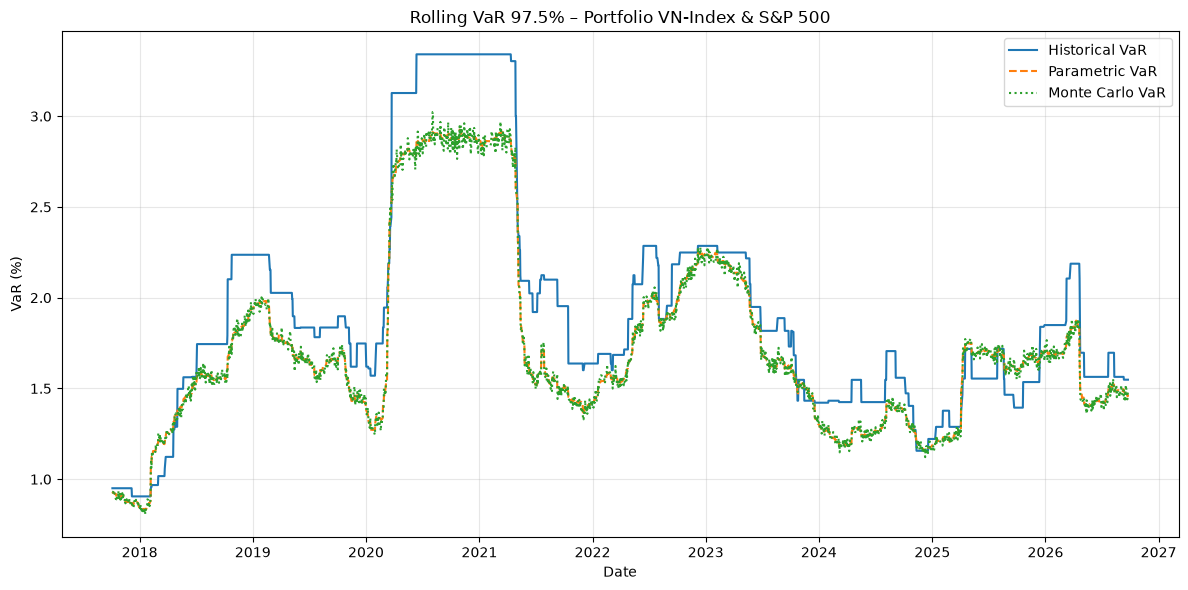

Đã lưu: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\outputs\figures\rolling_var_975.png


In [44]:
# ============================================================
# ROLLING VaR FIGURE
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    rolling_var.index,
    rolling_var["VaR_Historical"] * 100,
    label="Historical VaR"
)

plt.plot(
    rolling_var.index,
    rolling_var["VaR_Parametric"] * 100,
    label="Parametric VaR",
    linestyle="--"
)

plt.plot(
    rolling_var.index,
    rolling_var["VaR_MonteCarlo"] * 100,
    label="Monte Carlo VaR",
    linestyle=":"
)

plt.title("Rolling VaR 97.5% – Portfolio VN-Index & S&P 500")
plt.xlabel("Date")
plt.ylabel("VaR (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "rolling_var_975.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu:", figure_path)

In [45]:
# ============================================================
# SAVE ROLLING VaR RESULTS
# ============================================================

rolling_var_path = OUTPUT_TABLES / "rolling_var_975.csv"

rolling_var.to_csv(rolling_var_path)

print("Đã lưu:", rolling_var_path)

Đã lưu: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\outputs\tables\rolling_var_975.csv


In [46]:
# ============================================================
# IMPORT GARCH MODEL
# ============================================================

from src.garch.garch_model import calculate_garch_var_es_rolling

print("GARCH model imported successfully.")

GARCH model imported successfully.


In [47]:
# ============================================================
# ROLLING GARCH(1,1) + VaR + ES 97.5%
# ============================================================

garch_results = calculate_garch_var_es_rolling(
    portfolio_return_series,
    window=ROLLING_WINDOW,
    conf_level=CONF_LEVEL
)

print("Shape:", garch_results.shape)
print("Start:", garch_results.index.min())
print("End:", garch_results.index.max())

garch_results.head()

Shape: (2132, 3)
Start: 2017-10-05 00:00:00
End: 2026-09-24 00:00:00


,GARCH_Volatility,VaR_GARCH,ES_97_5
Date,,,
2017-10-05,0.005064,0.009182,0.011096
2017-10-06,0.005022,0.009128,0.011025
2017-10-09,0.005011,0.009122,0.011015
2017-10-10,0.004985,0.009047,0.010930
2017-10-11,0.004966,0.008999,0.010875


In [48]:
# ============================================================
# GARCH + ES SUMMARY
# ============================================================

garch_results.describe()

,GARCH_Volatility,VaR_GARCH,ES_97_5
count,2132.000000,2132.000000,2132.000000
mean,0.008691,0.016172,0.019456
std,0.004232,0.008407,0.010003
min,0.004015,0.006773,0.008290
25%,0.006657,0.012123,0.014665
50%,0.007710,0.014090,0.016994
75%,0.009563,0.018031,0.021671
max,0.063117,0.123312,0.147160


In [49]:
# ============================================================
# LATEST GARCH VaR & ES
# ============================================================

garch_results.tail(1)

,GARCH_Volatility,VaR_GARCH,ES_97_5
Date,,,
2026-09-24,0.0069,0.012989,0.015596


In [50]:
# ============================================================
# SAVE GARCH RESULTS
# ============================================================

garch_path = OUTPUT_TABLES / "garch_var_es_rolling_975.csv"

garch_results.to_csv(garch_path)

print("Đã lưu:", garch_path)

Đã lưu: d:\GÓI 1\chủ đề 3 - tuần 4\market-risk-measurement\outputs\tables\garch_var_es_rolling_975.csv


In [51]:
# ============================================================
# CHECK CURRENT OUTPUTS
# ============================================================

print("Output tables:")

for file in sorted(OUTPUT_TABLES.iterdir()):
    print("-", file.name)

print("\nOutput figures:")

for file in sorted(OUTPUT_FIGURES.iterdir()):
    print("-", file.name)

Output tables:
- .gitkeep
- garch_var_es_rolling_975.csv
- rolling_var_975.csv

Output figures:
- .gitkeep
- rolling_var_975.png


In [52]:
# ============================================================
# LATEST VaR RESULTS
# ============================================================

latest_var = rolling_var.tail(1).copy()

latest_var["VaR_Historical_%"] = latest_var["VaR_Historical"] * 100
latest_var["VaR_Parametric_%"] = latest_var["VaR_Parametric"] * 100
latest_var["VaR_MonteCarlo_%"] = latest_var["VaR_MonteCarlo"] * 100

latest_var[
    [
        "VaR_Historical_%",
        "VaR_Parametric_%",
        "VaR_MonteCarlo_%"
    ]
]

,VaR_Historical_%,VaR_Parametric_%,VaR_MonteCarlo_%
Date,,,
2026-09-24,1.548322,1.464483,1.483327


In [53]:
# ============================================================
# LATEST GARCH + ES RESULTS
# ============================================================

latest_garch = garch_results.tail(1).copy()

latest_garch["GARCH_Volatility_%"] = (
    latest_garch["GARCH_Volatility"] * 100
)

latest_garch["VaR_GARCH_%"] = (
    latest_garch["VaR_GARCH"] * 100
)

latest_garch["ES_97_5_%"] = (
    latest_garch["ES_97_5"] * 100
)

latest_garch[
    [
        "GARCH_Volatility_%",
        "VaR_GARCH_%",
        "ES_97_5_%"
    ]
]

,GARCH_Volatility_%,VaR_GARCH_%,ES_97_5_%
Date,,,
2026-09-24,0.690037,1.298875,1.559597
